# 🏦 Loan Approval Prediction using Random Forest


## 📌 Problem Statement
Predict whether a loan application will be **Approved or Rejected** based on applicant details.

**Target Column:** Loan_Status  
- Y → Loan Approved  
- N → Loan Rejected


## 1️⃣ Import Required Libraries

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


## 2️⃣ Load Dataset

In [3]:

df = pd.read_csv("train.csv")  # Update path if needed
df.head(10)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,Y
6,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
7,LP001014,Male,Yes,3+,Graduate,No,3036,2504.0,158.0,360.0,0.0,Semiurban,N
8,LP001018,Male,Yes,2,Graduate,No,4006,1526.0,168.0,360.0,1.0,Urban,Y
9,LP001020,Male,Yes,1,Graduate,No,12841,10968.0,349.0,360.0,1.0,Semiurban,N


## 3️⃣ Basic Data Exploration

In [4]:

df.shape


(614, 13)

In [5]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [6]:

df.isnull().sum()


,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


## 4️⃣ Handle Missing Values

In [7]:

# Numerical columns
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].median())
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].median())


df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])



## 5️⃣ Drop Irrelevant Column

In [8]:

df.drop('Loan_ID', axis=1, inplace=True)


## 6️⃣ Encode Categorical Variables

In [9]:

df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Gender_Male,Married_Yes,Dependents_1,Dependents_2,Dependents_3+,Education_Not Graduate,Self_Employed_Yes,Property_Area_Semiurban,Property_Area_Urban,Loan_Status_Y
0,5849,0.0,128.0,360.0,1.0,True,False,False,False,False,False,False,False,True,True
1,4583,1508.0,128.0,360.0,1.0,True,True,True,False,False,False,False,False,False,False
2,3000,0.0,66.0,360.0,1.0,True,True,False,False,False,False,True,False,True,True
3,2583,2358.0,120.0,360.0,1.0,True,True,False,False,False,True,False,False,True,True
4,6000,0.0,141.0,360.0,1.0,True,False,False,False,False,False,False,False,True,True


## 7️⃣ Split Features and Target

In [10]:

X = df_encoded.drop('Loan_Status_Y', axis=1)
y = df_encoded['Loan_Status_Y']


## 8️⃣ Train-Test Split

In [11]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## 9️⃣ Train Random Forest Model

In [12]:

rf = RandomForestClassifier(
    n_estimators=50,
    max_depth=5,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, n_estimators=50, random_state=42)

## 🔟 Model Prediction

In [13]:

y_pred = rf.predict(X_test)


## 1️⃣1️⃣ Model Evaluation

In [14]:

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print(classification_report(y_test, y_pred))


Accuracy: 0.7886178861788617
              precision    recall  f1-score   support

       False       0.95      0.42      0.58        43
        True       0.76      0.99      0.86        80

    accuracy                           0.79       123
   macro avg       0.85      0.70      0.72       123
weighted avg       0.83      0.79      0.76       123



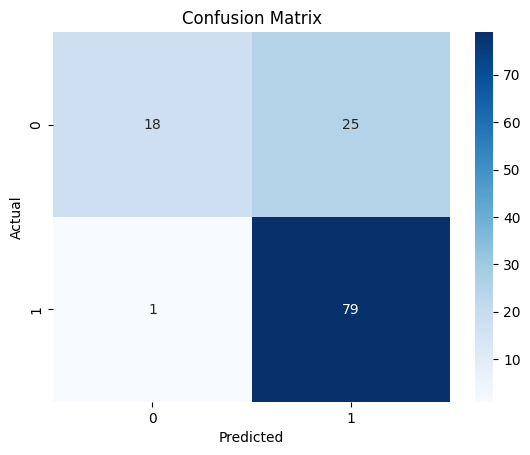

In [15]:

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


## 1️⃣2️⃣ Feature Importance

In [19]:

feature_importance = pd.Series(
    rf.feature_importances_, index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)


,0
Credit_History,0.472689
LoanAmount,0.102340
ApplicantIncome,0.096864
CoapplicantIncome,0.072262
Loan_Amount_Term,0.069315
Property_Area_Semiurban,0.050474
Married_Yes,0.037980
Education_Not Graduate,0.025660
Property_Area_Urban,0.017553
Dependents_1,0.015092


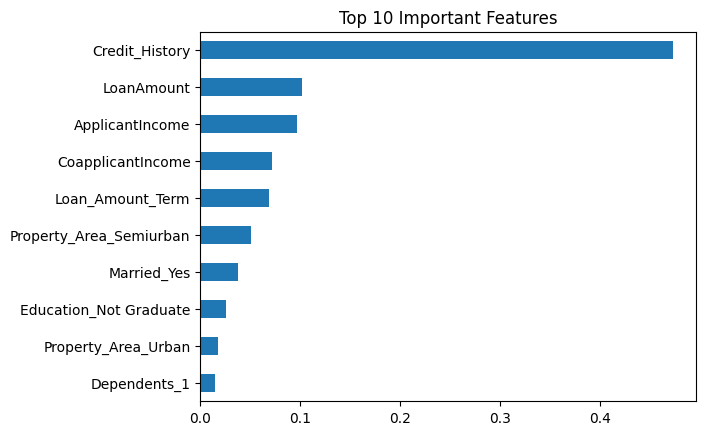

In [20]:

feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()


**make new predictions**

In [17]:
new_data = pd.DataFrame([{
    'ApplicantIncome': 6000,
    'CoapplicantIncome': 1000.0,
    'LoanAmount': 140.0,
    'Loan_Amount_Term': 360.0,
    'Credit_History': 1.0,
    'Gender_Male': 1,                 # Male
    'Married_Yes': 0,                 # Not married
    'Dependents_1': 0,
    'Dependents_2': 0,
    'Dependents_3+': 0,
    'Education_Not Graduate': 0,      # Graduate
    'Self_Employed_Yes': 0,
    'Property_Area_Semiurban': 0,
    'Property_Area_Urban': 1          # Urban
}])

new_prediction = rf.predict(new_data)

if new_prediction[0] == 1:
    print('Loan Status: Approved')
else:
    print('Loan Status: Rejected')



Loan Status: Approved


| Loan_Status_Y | Meaning      |
| ------------- | ------------ |
| 1             | Approved (Y) |
| 0             | Rejected (N) |



## 📊 Key Observations
- Credit_History is usually the most important feature  
- Random Forest handles non-linear patterns well  
- No feature scaling required  
- Robust to outliers  

## 🧠 Why Random Forest?
- Handles categorical + numerical data  
- Reduces overfitting compared to Decision Tree  
- Provides feature importance  
- Works well on small datasets
